# Performance Topology

This notebook gives a compact global view: who performs well overall, how ranking changes by dataset, and where each method tends to win.

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
from analysis_helpers import (
    ALGORITHM_ORDER,
    ALGORITHM_PALETTE,
    HEATMAP_CMAP,
    contamination_stratum,
    dimensionality_stratum,
    load_descriptive_stats,
    load_phase4_summary,
    save_figure,
    setup_theme,
    split_quantitative_cohorts,
)

setup_theme()
summary = load_phase4_summary()
descriptive_full = load_descriptive_stats().rename(columns={"dataset_id": "dataset"})
descriptive = descriptive_full[["dataset", "contamination", "n_features", "outlier_count"]].copy()
quantitative_meta, visual_only_meta = split_quantitative_cohorts(descriptive)
frame = summary.merge(descriptive, on="dataset", how="left")
frame_quantitative = frame[frame["outlier_count"] > 0].copy()

print(f"Quantitative cohort datasets: {quantitative_meta['dataset'].nunique()}")
print(f"Visual-only cohort datasets: {visual_only_meta['dataset'].nunique()}")
print("Visual-only IDs:", ", ".join(sorted(visual_only_meta["dataset"].tolist())))

frame_quantitative.head()

Quantitative cohort datasets: 28
Visual-only cohort datasets: 9
Visual-only IDs: fcps/lsun, graves/fuzzyx, sipu/compound, sipu/jain, sipu/spiral, wut/circles, wut/isolation, wut/smile, wut/windows


,run_name,dataset,algorithm,variant,seed,pr_auc,roc_auc,mcc,f1,distance_concentration_ratio,n_features_x,pca_variance,recall_type_g,recall_type_l,contamination,n_features_y,outlier_count
0,phase4__thyroid__IForest__seed-42__task-003314...,thyroid,IForest,bootstrap-iforest-stable,42,0.669421,0.983536,0.650914,0.659574,45.091528,6.0,NaN,NaN,NaN,0.024655,6,93
1,phase4__pima__OCSVM__seed-42__task-003313__cfg...,pima,OCSVM,lhs-ocsvm-pima,42,0.492475,0.655724,0.246981,0.510242,2.615846,8.0,NaN,NaN,NaN,0.348958,8,268
2,phase4__ionosphere__OCSVM__seed-42__task-00331...,ionosphere,OCSVM,lhs-ocsvm-ionosphere,42,0.902870,0.906279,0.721928,0.822134,2.314527,32.0,NaN,NaN,NaN,0.358974,32,126
3,phase4__breastw__OCSVM__seed-42__task-003311__...,breastw,OCSVM,lhs-ocsvm-breastw,42,0.933811,0.978872,0.868187,0.914405,3.638783,9.0,NaN,NaN,NaN,0.349927,9,239
4,phase4__pima__OCSVM__seed-42__task-003310__cfg...,pima,OCSVM,sobol-ocsvm-pima,42,0.492005,0.655522,0.235528,0.502793,2.615846,8.0,NaN,NaN,NaN,0.348958,8,268


PosixPath('/Users/pawelp/Desktop/education/pw/data_exp/anomaly_detection/outputs/figures/topology_pr_auc_distribution.png')

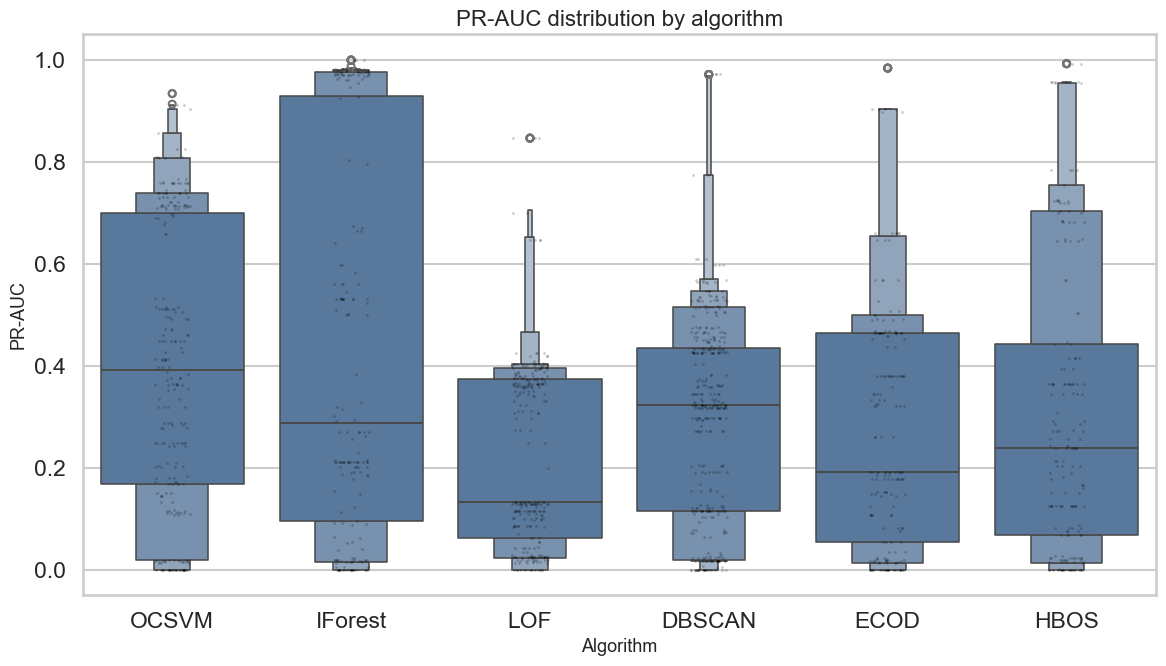

In [2]:
fig, ax = plt.subplots(figsize=(12, 7))
sns.boxenplot(
    data=frame,
    x="algorithm",
    y="pr_auc",
    order=ALGORITHM_ORDER,
    dodge=False,
    legend=False,
    ax=ax,
)
sns.stripplot(
    data=frame.sample(min(1500, len(frame)), random_state=42),
    x="algorithm",
    y="pr_auc",
    order=ALGORITHM_ORDER,
    color="black",
    alpha=0.2,
    size=2,
    ax=ax,
)
ax.set_title("PR-AUC distribution by algorithm")
ax.set_xlabel("Algorithm")
ax.set_ylabel("PR-AUC")
plt.tight_layout()
# annotate_figure(
#     fig, "PR-AUC distribution over all phase4 runs (all variants and seeds pooled by algorithm)."
# )
save_figure("topology_pr_auc_distribution.png")

PosixPath('/Users/pawelp/Desktop/education/pw/data_exp/anomaly_detection/outputs/figures/topology_roc_minus_pr_gap.png')

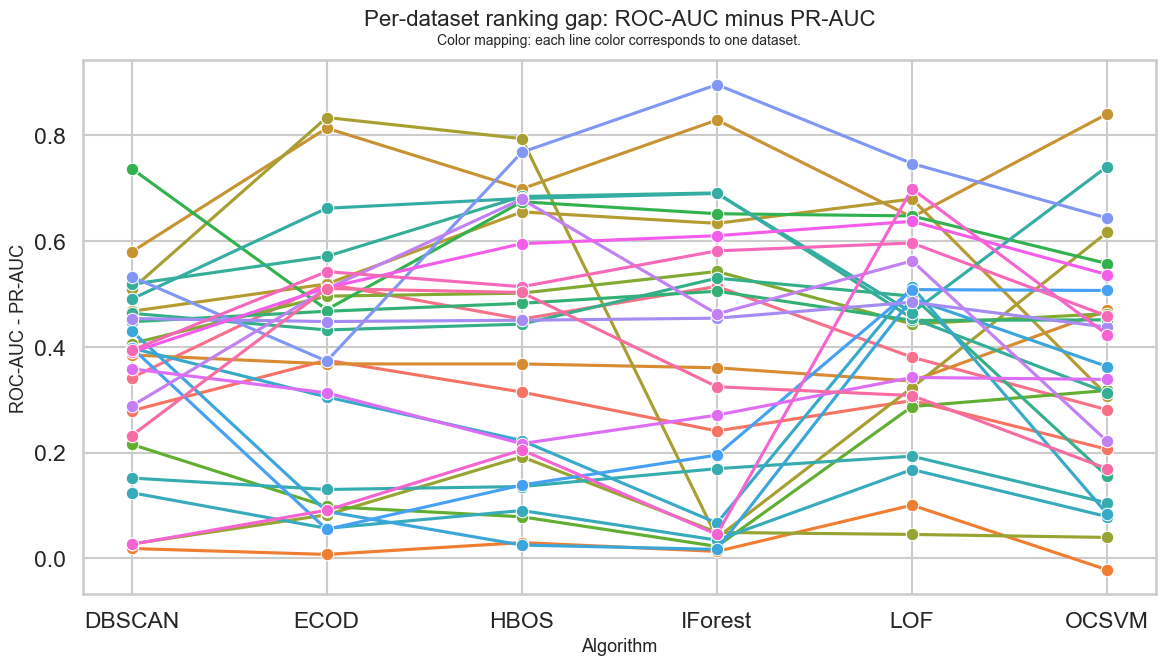

In [3]:
agg = frame_quantitative.groupby(["dataset", "algorithm"], as_index=False)[
    ["pr_auc", "roc_auc"]
].median()
agg["gap_roc_minus_pr"] = agg["roc_auc"] - agg["pr_auc"]
fig, ax = plt.subplots(figsize=(12, 7))
sns.lineplot(
    data=agg, x="algorithm", y="gap_roc_minus_pr", hue="dataset", legend=False, marker="o", ax=ax
)
ax.set_title("Per-dataset ranking gap: ROC-AUC minus PR-AUC", y=1.05)
ax.text(
    0.5,
    1.05,
    "Color mapping: each line color corresponds to one dataset.",
    transform=ax.transAxes,
    ha="center",
    va="top",
    fontsize=10,
)
ax.set_xlabel("Algorithm")
ax.set_ylabel("ROC-AUC - PR-AUC")
plt.tight_layout()
# annotate_figure(
#     fig, "Per dataset+algorithm medians from all phase4 runs; one line equals one dataset."
# )
save_figure("topology_roc_minus_pr_gap.png")

,dataset,winner,contamination_band,dimensionality_band,winner_pr_auc
2,breastw,ECOD,high (>=30%),low-d (<15),0.983928
15,pima,HBOS,high (>=30%),low-d (<15),0.568824
7,ionosphere,LOF,high (>=30%),mid-d (15-79),0.846516
16,satellite,HBOS,high (>=30%),mid-d (15-79),0.700413
11,mnist,ECOD,low (2-10%),high-d (>=80),0.320947
12,musk,IForest,low (2-10%),high-d (>=80),0.210490
18,shuttle,IForest,low (2-10%),low-d (<15),0.980313
25,wbc,DBSCAN,low (2-10%),low-d (<15),0.971429
22,thyroid,OCSVM,low (2-10%),low-d (<15),0.761415
27,wut/x2,LOF,low (2-10%),low-d (<15),0.646738


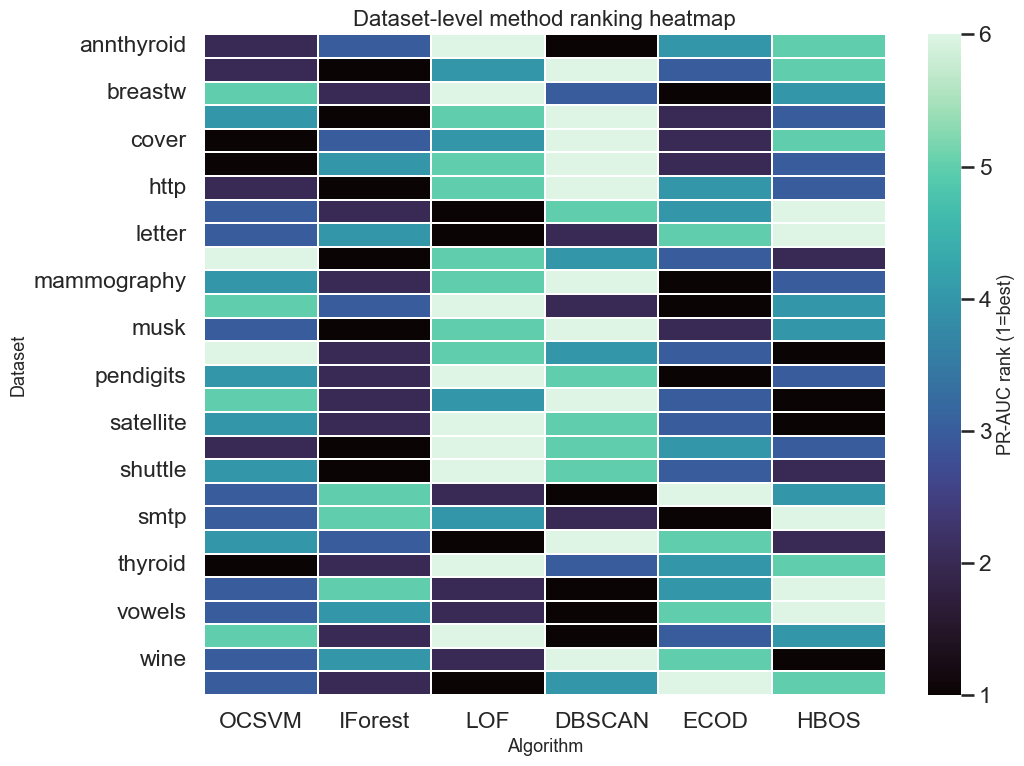

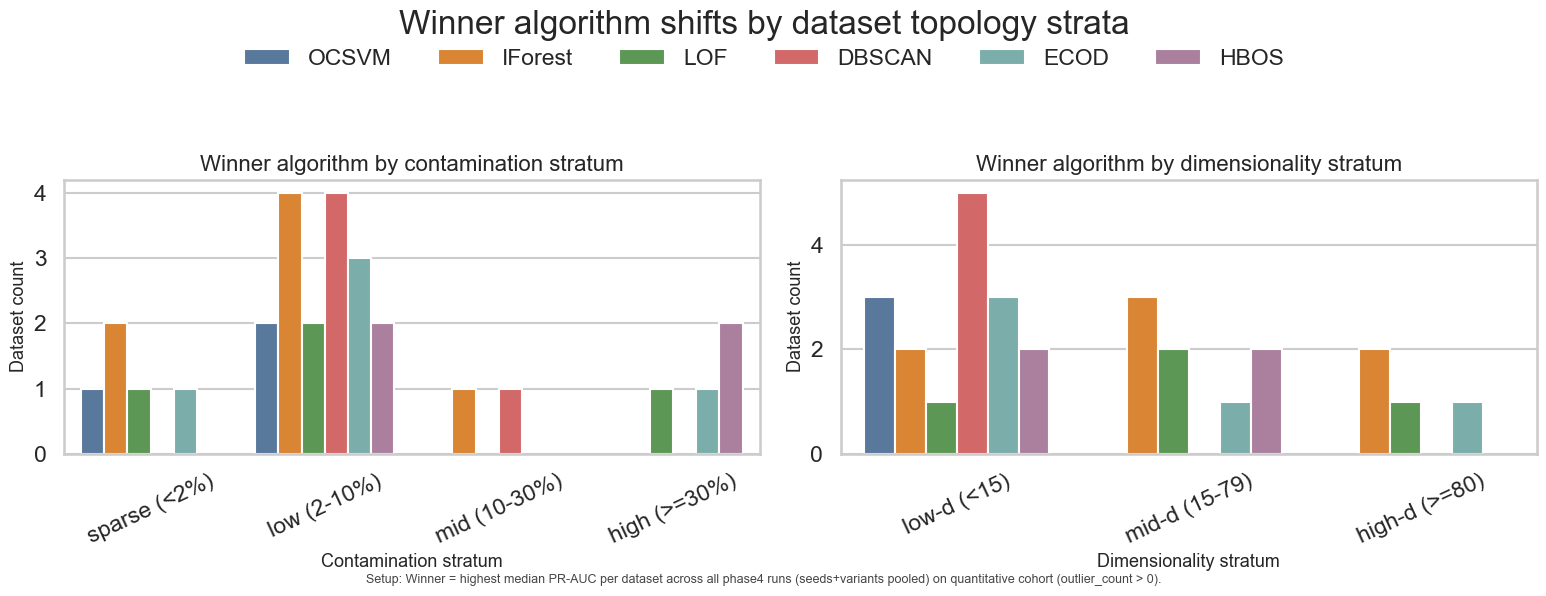

In [ ]:
ranked = agg.copy()
ranked["rank"] = ranked.groupby("dataset")["pr_auc"].rank(ascending=False, method="average")
pivot = ranked.pivot(index="dataset", columns="algorithm", values="rank").reindex(
    columns=ALGORITHM_ORDER
)
fig, ax = plt.subplots(figsize=(11, max(8, len(pivot) * 0.28)))
sns.heatmap(
    pivot,
    cmap=HEATMAP_CMAP,
    linewidths=0.2,
    cbar_kws={"label": "PR-AUC rank (1=best)"},
    ax=ax,
)
ax.set_title("Dataset-level method ranking heatmap")
ax.set_xlabel("Algorithm")
ax.set_ylabel("Dataset")
plt.tight_layout()
# annotate_figure(fig, "Rank computed from per-dataset median PR-AUC over all phase4 runs and seeds.")  # noqa: E501
save_figure("topology_rank_heatmap.png")
strata = descriptive.assign(
    contamination_band=lambda d: d["contamination"].apply(contamination_stratum),
    dimensionality_band=lambda d: d["n_features"].apply(dimensionality_stratum),
)
winner = ranked.loc[
    ranked.groupby("dataset")["pr_auc"].idxmax(), ["dataset", "algorithm", "pr_auc"]
].rename(columns={"algorithm": "winner", "pr_auc": "winner_pr_auc"})
strata_winner = winner.merge(strata, on="dataset", how="left")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
order_contam = ["sparse (<2%)", "low (2-10%)", "mid (10-30%)", "high (>=30%)"]
sns.countplot(
    data=strata_winner,
    x="contamination_band",
    hue="winner",
    order=order_contam,
    hue_order=ALGORITHM_ORDER,
    palette=ALGORITHM_PALETTE,
    ax=axes[0],
)
axes[0].set_title("Winner algorithm by contamination stratum")
axes[0].set_xlabel("Contamination stratum")
axes[0].set_ylabel("Dataset count")
axes[0].tick_params(axis="x", rotation=25)
order_dim = ["low-d (<15)", "mid-d (15-79)", "high-d (>=80)"]
sns.countplot(
    data=strata_winner,
    x="dimensionality_band",
    hue="winner",
    order=order_dim,
    hue_order=ALGORITHM_ORDER,
    palette=ALGORITHM_PALETTE,
    ax=axes[1],
)
axes[1].set_title("Winner algorithm by dimensionality stratum")
axes[1].set_xlabel("Dimensionality stratum")
axes[1].set_ylabel("Dataset count")
axes[1].tick_params(axis="x", rotation=25)
for ax in axes:
    legend = ax.get_legend()
    if legend is not None:
        legend.remove()
handles, labels = axes[1].get_legend_handles_labels()
plt.suptitle("Winner algorithm shifts by dataset topology strata", fontsize=24, y=0.98)
fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 0.95), ncol=6, frameon=False)
plt.tight_layout(rect=(0, 0, 1, 0.88))
fig.text(
    0.5,
    0.02,
    (
        "Setup: Winner = highest median PR-AUC per dataset "
        "across all phase4 runs (seeds+variants pooled) on quantitative cohort (outlier_count > 0)."
    ),
    ha="center",
    va="bottom",
    fontsize=9,
    alpha=0.85,
)
save_figure("topology_winner_by_strata.png")
strata_winner[
    ["dataset", "winner", "contamination_band", "dimensionality_band", "winner_pr_auc"]
].sort_values(
    ["contamination_band", "dimensionality_band", "winner_pr_auc"],
    ascending=[True, True, False],
).head(20)

## Seed Stability Snapshot

These plots isolate seed-driven variability. The goal is to separate genuine method differences from random-run noise.

,algorithm,median_seed_std,median_seed_range
0,DBSCAN,0.000000,0.0000
1,ECOD,0.000000,0.0000
2,HBOS,0.000000,0.0000
4,LOF,0.000000,0.0000
5,OCSVM,0.000000,0.0000
3,IForest,0.012662,0.0334


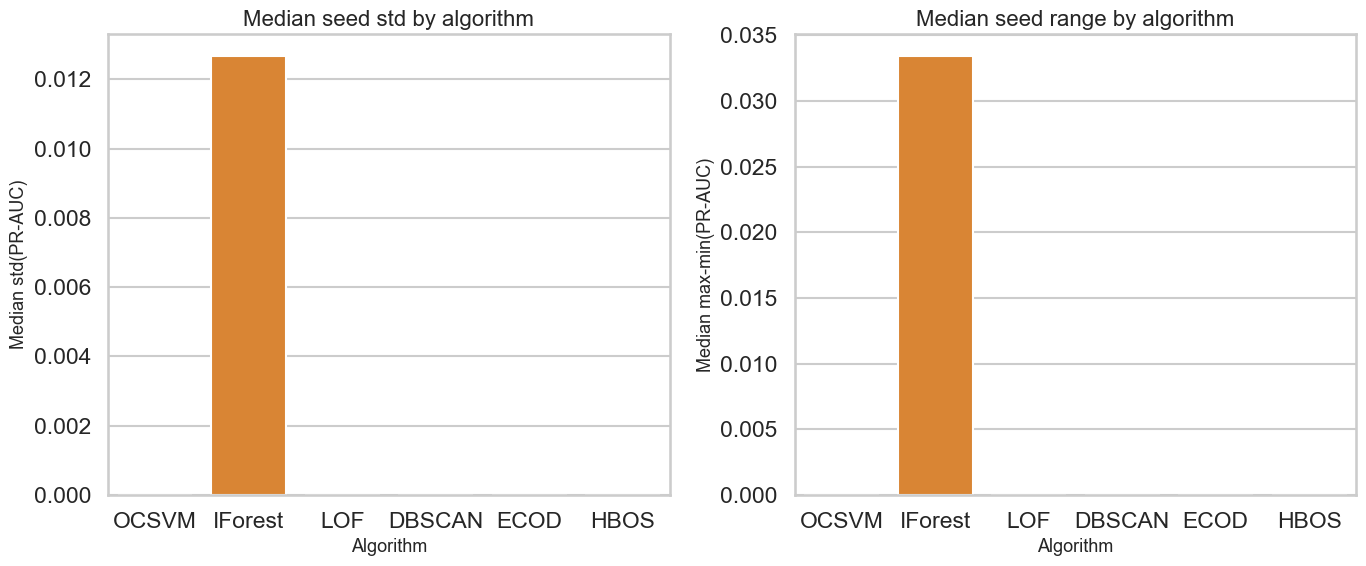

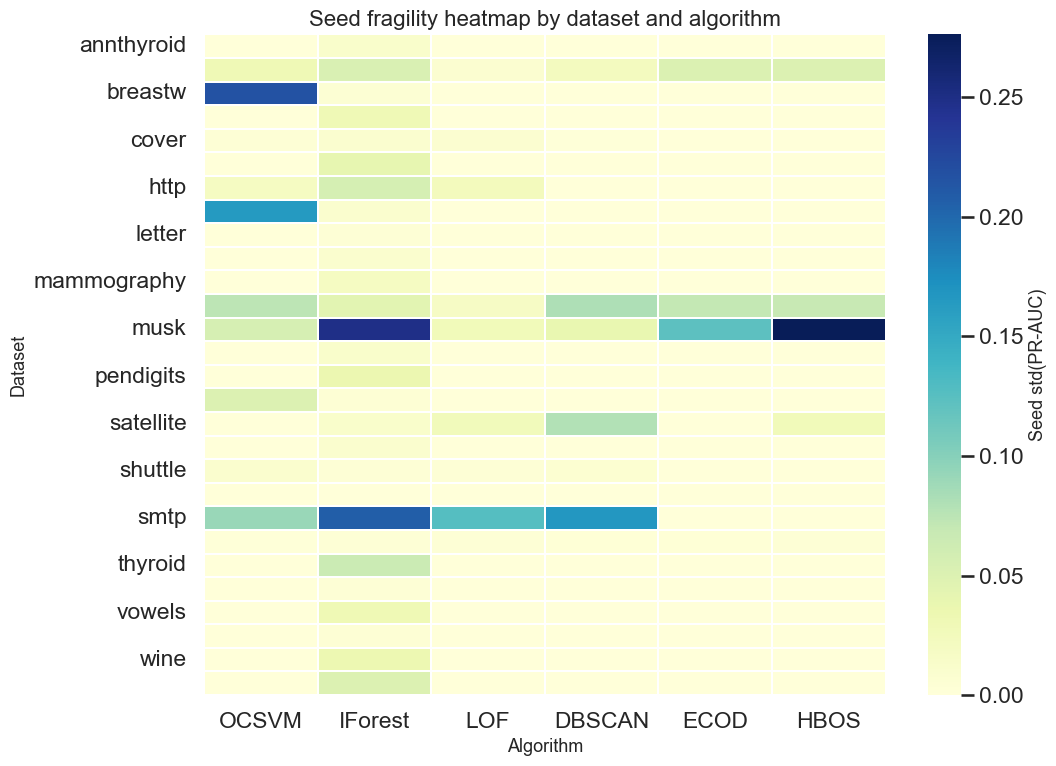

In [5]:
seed_stats = (
    frame_quantitative.groupby(["dataset", "algorithm"], as_index=False)["pr_auc"]
    .agg(["mean", "std", "min", "max"])
    .reset_index()
    .rename(
        columns={
            "mean": "pr_auc_mean",
            "std": "pr_auc_std",
            "min": "pr_auc_min",
            "max": "pr_auc_max",
        }
    )
)
seed_stats["pr_auc_range"] = seed_stats["pr_auc_max"] - seed_stats["pr_auc_min"]
alg_stability = (
    seed_stats.groupby("algorithm", as_index=False)[["pr_auc_std", "pr_auc_range"]]
    .median()
    .rename(columns={"pr_auc_std": "median_seed_std", "pr_auc_range": "median_seed_range"})
)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.barplot(
    data=alg_stability,
    x="algorithm",
    y="median_seed_std",
    hue="algorithm",
    order=ALGORITHM_ORDER,
    hue_order=ALGORITHM_ORDER,
    palette=ALGORITHM_PALETTE,
    legend=False,
    ax=axes[0],
)
axes[0].set_title("Median seed std by algorithm")
axes[0].set_xlabel("Algorithm")
axes[0].set_ylabel("Median std(PR-AUC)")
sns.barplot(
    data=alg_stability,
    x="algorithm",
    y="median_seed_range",
    hue="algorithm",
    order=ALGORITHM_ORDER,
    hue_order=ALGORITHM_ORDER,
    palette=ALGORITHM_PALETTE,
    legend=False,
    ax=axes[1],
)
axes[1].set_title("Median seed range by algorithm")
axes[1].set_xlabel("Algorithm")
axes[1].set_ylabel("Median max-min(PR-AUC)")
plt.tight_layout()
# annotate_figure(
#     fig,
#     ("Seed stability from repeated runs: median std/range of PR-AUC across "
#      "seeds per dataset, then aggregated by algorithm."),
# )
save_figure("topology_seed_stability_bars.png")
seed_pivot = seed_stats.pivot(index="dataset", columns="algorithm", values="pr_auc_std").reindex(
    columns=ALGORITHM_ORDER
)
fig, ax = plt.subplots(figsize=(11, max(8, len(seed_pivot) * 0.28)))
sns.heatmap(
    seed_pivot, cmap="YlGnBu", linewidths=0.2, cbar_kws={"label": "Seed std(PR-AUC)"}, ax=ax
)
ax.set_title("Seed fragility heatmap by dataset and algorithm")
ax.set_xlabel("Algorithm")
ax.set_ylabel("Dataset")
plt.tight_layout()
# annotate_figure(fig, "Heatmap value = std(PR-AUC) across seeds for each dataset+algorithm group.")
save_figure("topology_seed_fragility_heatmap.png")
alg_stability.sort_values("median_seed_std")